In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [ ]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # Normal trainable weights
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.01
        )

        # Normal trainable bias
        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

        # Learnable gate scores
        # Same size as weight matrix
        self.gate_scores = nn.Parameter(
            torch.zeros(out_features, in_features)
        )

    def forward(self, x):

        # Convert gate scores into values between 0 and 1
        gates = torch.sigmoid(self.gate_scores)

        # Apply pruning effect
        pruned_weights = self.weight * gates

        # Linear layer operation
        output = torch.matmul(x, pruned_weights.t()) + self.bias

        return output

In [ ]:
class SelfPruningNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Input: 32x32x3 = 3072
        self.fc1 = PrunableLinear(3072, 256)

        # Hidden layer
        self.fc2 = PrunableLinear(256, 128)

        # Output layer (10 CIFAR classes)
        self.fc3 = PrunableLinear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        # Flatten image
        x = x.view(x.size(0), -1)

        # Layer 1
        x = self.relu(self.fc1(x))

        # Layer 2
        x = self.relu(self.fc2(x))

        # Output layer
        x = self.fc3(x)

        return x

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

# Training data
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Test data
test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 170M/170M [00:04<00:00, 36.0MB/s]


Train samples: 50000
Test samples: 10000


In [ ]:
# Smaller subset for faster execution
train_subset = Subset(train_dataset, range(5000))
test_subset = Subset(test_dataset, range(1000))

print("Subset Train:", len(train_subset))
print("Subset Test:", len(test_subset))

Subset Train: 5000
Subset Test: 1000


In [ ]:
train_loader = DataLoader(
    train_subset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=64,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 79
Test batches: 16


In [ ]:
def compute_sparsity_loss(model):
    total_loss = 0

    for layer in model.modules():

        if isinstance(layer, PrunableLinear):

            gates = torch.sigmoid(layer.gate_scores)

            total_loss += gates.sum()

    return total_loss

In [ ]:
temp_model = SelfPruningNet()
print(compute_sparsity_loss(temp_model))

tensor(410230.0312, grad_fn=<AddBackward0>)


In [ ]:
def train_model(lambda_value, epochs=5):

    model = SelfPruningNet().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # clear old gradients
            optimizer.zero_grad()

            # forward pass
            outputs = model(images)

            # classification loss
            classification_loss = criterion(outputs, labels)

            # pruning loss
            sparsity = compute_sparsity_loss(model)

            # total loss
            total_loss = classification_loss + (
                lambda_value * sparsity
            )

            # backpropagation
            total_loss.backward()

            # update weights
            optimizer.step()

            running_loss += total_loss.item()

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {running_loss:.2f}"
        )

    return model

In [ ]:
model = SelfPruningNet().to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
def train_model(lambda_value, epochs=5):

    model = SelfPruningNet().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            classification_loss = criterion(outputs, labels)

            sparsity = compute_sparsity_loss(model)

            total_loss = classification_loss + (
                lambda_value * sparsity
            )

            total_loss.backward()

            optimizer.step()

            running_loss += total_loss.item()

        print(
            f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.2f}"
        )

    return model

In [ ]:
model = train_model(
    lambda_value=0.001,
    epochs=3
)

Epoch 1/3 | Loss: 32069.53
Epoch 2/3 | Loss: 31001.24
Epoch 3/3 | Loss: 29943.74


In [ ]:
def evaluate_accuracy(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [ ]:
acc = evaluate_accuracy(model)
print("Test Accuracy:", acc, "%")

Test Accuracy: 25.7 %


In [ ]:
def calculate_sparsity(model, threshold=0.01):

    total = 0
    pruned = 0

    for layer in model.modules():

        if isinstance(layer, PrunableLinear):

            gates = torch.sigmoid(layer.gate_scores)

            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

In [ ]:
sp = calculate_sparsity(model)
print("Sparsity:", sp, "%")

Sparsity: 0.000609399375975039 %


In [ ]:
lambda_values = [0.001, 0.01, 0.1]

results = []

for lam in lambda_values:

    print("\nRunning Lambda =", lam)

    model = train_model(
        lambda_value=lam,
        epochs=3
    )

    acc = evaluate_accuracy(model)
    sp = calculate_sparsity(model)

    results.append([lam, acc, sp])

    print("Accuracy:", acc)
    print("Sparsity:", sp)


Running Lambda = 0.001
Epoch 1/3 | Loss: 32063.99
Epoch 2/3 | Loss: 30995.13
Epoch 3/3 | Loss: 29935.54
Accuracy: 25.6
Sparsity: 0.000609399375975039

Running Lambda = 0.01
Epoch 1/3 | Loss: 319035.95
Epoch 2/3 | Loss: 308457.96
Epoch 3/3 | Loss: 297920.20
Accuracy: 23.8
Sparsity: 0.000609399375975039

Running Lambda = 0.1
Epoch 1/3 | Loss: 3188318.96
Epoch 2/3 | Loss: 3082629.38
Epoch 3/3 | Loss: 2977286.41
Accuracy: 24.3
Sparsity: 0.0004875195007800312


In [ ]:
model = train_model(lambda_value=0.1, epochs=5)
acc = evaluate_accuracy(model)
sp = calculate_sparsity(model)
print(acc, sp)

Epoch 1/5 | Loss: 3177895.45
Epoch 2/5 | Loss: 3050209.84
Epoch 3/5 | Loss: 2923458.60
Epoch 4/5 | Loss: 2798248.49
Epoch 5/5 | Loss: 2675153.59
27.3 0.0


In [ ]:
def plot_gate_distribution(model):

    all_gates = []

    for layer in model.modules():

        if isinstance(layer, PrunableLinear):

            gates = torch.sigmoid(
                layer.gate_scores
            ).detach().cpu().numpy().flatten()

            all_gates.extend(gates)

    plt.figure(figsize=(8,5))
    plt.hist(all_gates, bins=30)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()

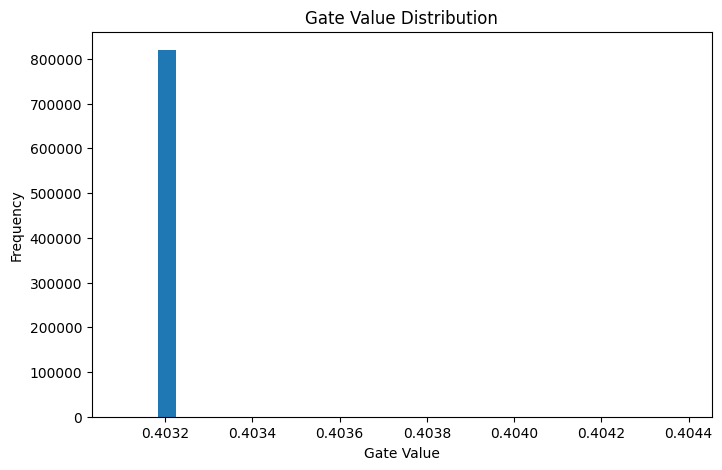

In [ ]:
plot_gate_distribution(model)

In [ ]:
all_vals = []

for layer in model.modules():
    if isinstance(layer, PrunableLinear):
        g = torch.sigmoid(layer.gate_scores).detach().cpu().numpy().flatten()
        all_vals.extend(g)

print("Average Gate:", np.mean(all_vals))
print("Min Gate:", np.min(all_vals))
print("Max Gate:", np.max(all_vals))

Average Gate: 0.4032102
Min Gate: 0.40309715
Max Gate: 0.40438867


In [ ]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

In [ ]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

train_subset = Subset(train_dataset, range(10000))
test_subset = Subset(test_dataset, range(2000))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=128, shuffle=False)

In [ ]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, temperature=0.5):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.02
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

        self.gate_scores = nn.Parameter(
            torch.zeros(out_features, in_features)
        )

        self.temperature = temperature

    def forward(self, x):

        gates = torch.sigmoid(
            self.gate_scores / self.temperature
        )

        pruned_weights = self.weight * gates

        return torch.matmul(x, pruned_weights.t()) + self.bias

In [ ]:
class SelfPruningNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc1 = PrunableLinear(64 * 8 * 8, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.features(x)

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [ ]:
model = train_model(
    lambda_value=0.01,
    epochs=10
)

Epoch 1/10 | Loss: 419465.29
Epoch 2/10 | Loss: 402602.69
Epoch 3/10 | Loss: 385869.44
Epoch 4/10 | Loss: 369344.85
Epoch 5/10 | Loss: 353100.75
Epoch 6/10 | Loss: 337206.10
Epoch 7/10 | Loss: 321717.71
Epoch 8/10 | Loss: 306686.07
Epoch 9/10 | Loss: 292153.00
Epoch 10/10 | Loss: 278145.70


In [ ]:
acc = evaluate_accuracy(model)
sp = calculate_sparsity(model, threshold=0.1)

print("Accuracy:", acc)
print("Sparsity:", sp)

Accuracy: 47.55
Sparsity: 0.0


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print("Total Parameters:", total_params)

Total Parameters: 2185034


In [ ]:
def train_model(lambda_value, epochs=10):

    model = SelfPruningNet().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    train_losses = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            classification_loss = criterion(outputs, labels)

            sparsity = compute_sparsity_loss(model)

            total_loss = classification_loss + (
                lambda_value * sparsity
            )

            total_loss.backward()

            optimizer.step()

            running_loss += total_loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Avg Loss: {avg_loss:.4f}"
        )

    return model, train_losses

In [ ]:
model, losses = train_model(
    lambda_value=0.01,
    epochs=10
)

Epoch 1/10 | Avg Loss: 5309.7024
Epoch 2/10 | Avg Loss: 5096.5225
Epoch 3/10 | Avg Loss: 4885.2553
Epoch 4/10 | Avg Loss: 4676.9514
Epoch 5/10 | Avg Loss: 4472.5029
Epoch 6/10 | Avg Loss: 4272.7031
Epoch 7/10 | Avg Loss: 4078.2913
Epoch 8/10 | Avg Loss: 3889.8732
Epoch 9/10 | Avg Loss: 3707.9200
Epoch 10/10 | Avg Loss: 3532.7915


In [ ]:
acc = evaluate_accuracy(model)
sp = calculate_sparsity(model, threshold=0.1)

print("Accuracy:", acc)
print("Sparsity:", sp)

Accuracy: 49.75
Sparsity: 0.0


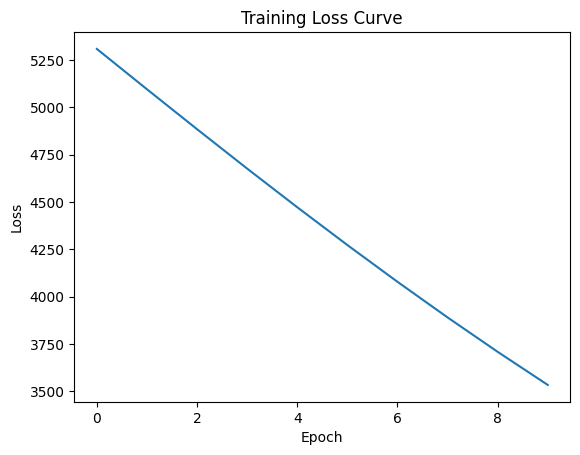

In [ ]:
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
all_vals = []

for layer in model.modules():
    if isinstance(layer, PrunableLinear):
        g = torch.sigmoid(layer.gate_scores).detach().cpu().numpy().flatten()
        all_vals.extend(g)

print("Average Gate:", np.mean(all_vals))
print("Min Gate:", np.min(all_vals))
print("Max Gate:", np.max(all_vals))

Average Gate: 0.31821263
Min Gate: 0.3178482
Max Gate: 0.45611143


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

2185034
